In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

In [2]:
def genHeatMap(w, h, cx, cy, r, mag):
    if cx <= 0 or cy <= 0:
        return np.zeros((h, w))
    x, y = np.meshgrid(np.linspace(1, w, w), np.linspace(1, h, h))
    heatmap = ((y - (cy + 1))**2) + ((x - (cx + 1))**2)
    heatmap[heatmap <= r**2] = 1
    heatmap[heatmap > r**2] = 0
    return heatmap*mag
     
def get_coordinates_from_heatmap(heatmap):
    # Flatten the heatmap to find the maximum value
    max_idx = np.argmax(heatmap)
    # Convert the flattened index to 2D coordinates
    y, x = np.unravel_index(max_idx, heatmap.shape)
    return x, y


In [3]:
class TrackNetDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y
    
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]
    
    def __len__(self):
        return len(self.X)

    @classmethod
    def from_directory(cls,dir_path):
        scale_x = 512 / 1280
        scale_y = 288 / 720
        frames = []
        heatmaps = []
        
        X = []
        y = []

        for direc in os.listdir(dir_path):
            if direc =='.DS_Store':
                continue
            for vid in os.listdir(os.path.join(dir_path,direc,'video')):
                if vid =='.DS_Store':
                    continue
                csv = pd.read_csv(os.path.join(dir_path,direc,'csv',vid.split('.')[0]+'_ball.csv'))
                video = cv2.VideoCapture(os.path.join(dir_path,direc,'video',vid))
                frame_cnt =0
                
                while True:
                    success, frame = video.read()
                    if not success:
                        break
                    elif frame_cnt>300:
                        break
                    else:
                        frame = cv2.resize(frame,(512,288))
                        new_x = int(csv.iloc[frame_cnt].X * scale_x)
                        new_y = int(csv.iloc[frame_cnt].Y * scale_y)
                        heatmap = genHeatMap(512,288,new_x,new_y,1,1)
                        heatmap = np.expand_dims(heatmap,axis=-1)
                        frame_cnt+=1
                        
                        frames.append(frame)
                        heatmaps.append(heatmap)
        
        for i in range(0,len(frames)):
            if i==0 or i==len(frames)-1:
                continue
            else:
                X.append(np.concatenate(np.asarray([frames[i-1],frames[i],frames[i+1]]),axis=-1))
                y.append(np.concatenate(np.asarray([heatmaps[i-1],heatmaps[i],heatmaps[i+1]]),axis=-1))
                
        X = np.asarray(X)/255.0
        y = np.asarray(y)/255.0
        return cls(torch.tensor(X,dtype=torch.float16),torch.tensor(y,dtype=torch.float16))

In [97]:
dataset = TrackNetDataset.from_directory('/Users/apple/Desktop/data/dir')

In [102]:
dataset.__getitem__(2)[0].shape

(288, 512, 9)

In [103]:
dataset.__getitem__(2)[1].shape

(288, 512, 3)

In [13]:
path = '/Users/apple/Desktop/data/match1/video/1_01_00.mp4'
video = cv2.VideoCapture(path)
frame_cnt =0
                
while True:
    success, frame = video.read()
    if not success:
        break
    elif frame_cnt>300:
        break
    else:
        csv = pd.read_csv(os.path.join('/Users/apple/Desktop/data/match1/','csv',vid.split('.')[0]+'_ball.csv'))
        frame = cv2.resize(frame,(512,288))
        new_x = int(csv.iloc[frame_cnt].X * scale_x)
        new_y = int(csv.iloc[frame_cnt].Y * scale_y)
        heatmap = genHeatMap(512,288,new_x,new_y,1,1)
        print(frame.shape)
        print(heatmap.shape)
        break

(288, 512, 3)
(288, 512)


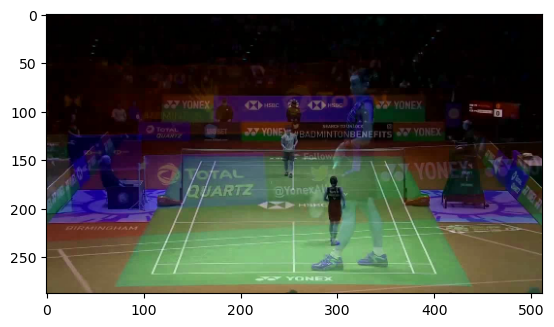

In [16]:
plt.imshow(frame)

In [9]:
vid = '1_01_00.mp4'
csv = pd.read_csv(os.path.join('/Users/apple/Desktop/data/match1/','csv',vid.split('.')[0]+'_ball.csv'))

In [10]:
csv.iloc[22]

Frame          22.0
Visibility      1.0
X             636.0
Y             346.0
Name: 22, dtype: float64

In [14]:
scale_x = 512 / 1280
scale_y = 288 / 720
new_x = int(csv.iloc[10].X * scale_x)
new_y = int(csv.iloc[10].Y * scale_y)
z = genHeatMap(512,288,new_x,new_y,1,1)

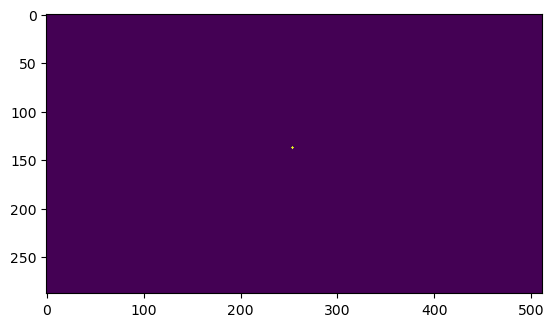

In [15]:
plt.imshow(z)

In [16]:
fx = [frame,frame,frame]
heatmap = z
heatmap = np.expand_dims(heatmap,axis=-1)
hx = [heatmap,heatmap,heatmap]
i = 1
X = np.concatenate(np.asarray([fx[i-1],fx[i],fx[i+1]]),axis=-1)
y = np.concatenate(np.asarray([hx[i-1],hx[i],hx[i+1]]),axis=-1)

In [154]:
y.shape

(288, 512, 3)

In [3]:
class TrackNetModel(nn.Module):
    def __init__(self):
        super(TrackNetModel,self).__init__()
        self.conv1 = nn.Conv2d(9,64,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(64,64,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.conv4 = nn.Conv2d(128,128,kernel_size=3,padding=1)
        self.conv5 = nn.Conv2d(128,256,kernel_size=3,padding=1)
        self.conv6 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.conv7 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.conv8 = nn.Conv2d(256,512,kernel_size=3,padding=1)
        self.conv9 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.conv10 = nn.Conv2d(512,512,kernel_size=3,padding=1)
        self.conv11 = nn.Conv2d(768,256,kernel_size=3,padding=1)
        self.conv12 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.conv13 = nn.Conv2d(256,256,kernel_size=3,padding=1)
        self.conv14 = nn.Conv2d(384,128,kernel_size=3,padding=1)
        self.conv15 = nn.Conv2d(128,128,kernel_size=3,padding=1)
        self.conv16 = nn.Conv2d(192,64,kernel_size=3,padding=1)
        self.conv17 = nn.Conv2d(64,64,kernel_size=3,padding=1)
        self.conv18 = nn.Conv2d(64,3,kernel_size=1)

        self.relu = nn.ReLU()
        self.batchn1 = nn.BatchNorm2d(64)
        self.batchn2 = nn.BatchNorm2d(128)
        self.batchn3 = nn.BatchNorm2d(256)
        self.batchn4 = nn.BatchNorm2d(512)
        self.maxp = nn.MaxPool2d(2,2)
        self.ups = nn.Upsample(scale_factor=2)
        
    def forward(self,x):
#         z = conv1(xt.permute(2,0,1).unsqueeze(0))
        z = self.conv1(x)
        z = self.batchn1(z)
        z = self.relu(z)

        z2 = self.conv2(z)
        z = self.batchn1(z2)
        z = self.relu(z)

        z = self.maxp(z)

        z = self.conv3(z)
        z = self.batchn2(z)
        z = self.relu(z)

        z4 = self.conv4(z)
        z = self.batchn2(z4)
        z = self.relu(z)

        z = self.maxp(z)

        z = self.conv5(z)
        z = self.batchn3(z)
        z = self.relu(z)

        z = self.conv6(z)
        z = self.batchn3(z)
        z = self.relu(z)

        z7 = self.conv7(z)
        z = self.batchn3(z7)
        z = self.relu(z)

        z = self.maxp(z)

        z = self.conv8(z)
        z = self.batchn4(z)
        z = self.relu(z)

        z = self.conv9(z)
        z = self.batchn4(z)
        z = self.relu(z)

        z = self.conv10(z)
        z = self.batchn4(z)
        z = self.relu(z)

        z = self.ups(z)

        z = torch.cat((z,z7),dim=1)

        z = self.conv11(z)
        z = self.batchn3(z)
        z = self.relu(z)

        z = self.conv12(z)
        z = self.batchn3(z)
        z = self.relu(z)

        z = self.conv13(z)
        z = self.batchn3(z)
        z = self.relu(z)

        z = self.ups(z)

        z = torch.cat((z,z4),dim=1)

        z = self.conv14(z)
        z = self.batchn2(z)
        z = self.relu(z)

        z = self.conv15(z)
        z = self.batchn2(z)
        z = self.relu(z)

        z = self.ups(z)
        z = torch.cat((z,z2),dim=1)

        z = self.conv16(z)
        z = self.batchn1(z)
        z = self.relu(z)

        z = self.conv17(z)
        z = self.batchn1(z)
        z = self.relu(z)

        z = self.conv18(z)
        # z = batchn1(z)
        z = self.relu(z)
        
        return z
    

torch.Size([1, 3, 288, 512])

In [15]:
class TrackNetDataset(Dataset):
    def __init__(self, root_dir, max_frames=300, img_size=(512, 288)):
        self.root_dir = root_dir
        self.img_w, self.img_h = img_size
        self.scale_x = self.img_w / 1280
        self.scale_y = self.img_h / 720
        self.samples = [] 
        for direc in os.listdir(root_dir):
            if direc == '.DS_Store': continue
            video_folder = os.path.join(root_dir, direc, 'video')
            csv_folder = os.path.join(root_dir, direc, 'csv')
            for vid in os.listdir(video_folder):
                if vid == '.DS_Store': continue
                video_path = os.path.join(video_folder, vid)
                csv_path = os.path.join(csv_folder, vid.split('.')[0] + '_ball.csv')
                cap = cv2.VideoCapture(video_path)
                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()


                frame_count = min(total_frames, max_frames)
                for i in range(1, frame_count - 1):
                    self.samples.append((video_path, csv_path, i))
        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, csv_path, center_idx = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        csv = pd.read_csv(csv_path)

        frames = []
        heatmaps = []
        for i in [center_idx - 1, center_idx, center_idx + 1]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            success, frame = cap.read()
            if not success:
                frame = np.zeros((self.img_h, self.img_w, 3), dtype=np.uint8)
            else:
                frame = cv2.resize(frame, (self.img_w, self.img_h))

 
            x_coord = int(csv.iloc[i].X * self.scale_x)
            y_coord = int(csv.iloc[i].Y * self.scale_y)
            heatmap = genHeatMap(self.img_w, self.img_h, x_coord, y_coord, r=1, mag=1)
            frames.append(frame)
            heatmaps.append(heatmap[..., None])  

        cap.release()

        X = np.concatenate(frames, axis=-1) / 255.0   
        y = np.concatenate(heatmaps, axis=-1) / 255.0 
        return (
            torch.tensor(X, dtype=torch.float32).permute(2, 0, 1),  
            torch.tensor(y, dtype=torch.float32).permute(2, 0, 1)   
        )


In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 1
dataset = TrackNetDataset('/Users/apple/Desktop/data/dir')
train_loader  = DataLoader(dataset=dataset,batch_size=BATCH_SIZE,shuffle=True)

In [26]:
dataset.__getitem__(100)[1].shape

torch.Size([3, 288, 512])

In [23]:
device = 'mps'
model = TrackNetModel().to(device).to(torch.float32)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adadelta(model.parameters(),lr=1.0)

In [28]:
from tqdm import tqdm_notebook

EPOCHS = 1

epoch_bar = tqdm_notebook(desc='training routine', 
                          total=EPOCHS,
                          position=0)

train_bar = tqdm_notebook(desc='split=train',
                          total=len(train_loader), 
                          position=1, 
                          leave=True)



for epoch in range(EPOCHS): 
    total_loss = 0
    total_acc = 0
    running_loss = 0.0
    running_acc = 0.0
    model.train()
    for idx,X in enumerate(train_loader):

        src, trg = X[0].to(device), X[1].to(device)
        trg = trg.argmax(dim=1).long()
        optimizer.zero_grad()
        output = model(src)  
#         print(output.shape,trg.shape)
        loss = criterion(output, trg)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        running_loss += (loss.item() - running_loss) / (idx + 1)
        
        train_bar.set_postfix(loss=running_loss, 
                                epoch=epoch)
        train_bar.update()
        
    loss = total_loss / len(train_loader)
    avg_loss = loss / len(train_loader)
    scheduler.step(avg_loss)

    epoch_bar.update()
    train_bar.n = 0


/var/folders/gf/jln4qrcs5qb4c5ywqfg9qmsr0000gn/T/ipykernel_1683/1393032900.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  epoch_bar = tqdm_notebook(desc='training routine',


training routine:   0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/gf/jln4qrcs5qb4c5ywqfg9qmsr0000gn/T/ipykernel_1683/1393032900.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  train_bar = tqdm_notebook(desc='split=train',


split=train:   0%|          | 0/298 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#save model
torch.save(model.state_dict(),'./model_dict.pt')
torch.save(model,'./model.pt')